# Diabetes Prediction using Decision Tree and Random Forest
**Dataset:** Pima Indians Diabetes Database (UCI / Kaggle)  
**Source:** https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database  
**Author:** Jenny Höglauer  
**Date:** 05/04/2026

## 1. Imports and Setup
We import all necessary libraries for data processing, machine learning, and visualization.

In [43]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Machine Learning - Utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# For reproducibility - same results every time we run
RANDOM_STATE = 42

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load and Explore the Dataset
The Pima Indians Diabetes dataset contains medical data from 768 female patients.  
The goal is to predict whether a patient has diabetes (Outcome = 1) or not (Outcome = 0).

In [44]:
# Load the dataset - make sure diabetes.csv is in the same folder as this notebook
df = pd.read_csv('diabetes.csv')

# Show the first 5 rows
print('Shape of dataset:', df.shape)
df.head()
# High Glucose Level reliably predicts Diabetes
# Skin Thickness demonstrates the lowest importance, likely due to measurement variability eg. size, muscle mass etc.

Shape of dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [45]:
# Basic statistics for each feature
df.describe()
# Glucose, Blood Pressure and BMI level at min 0 is biologically impossible
# Those outputs likely present missing data in the original dataset
# Zero Insulin values could indicate missing measurements rather than true clinical readings
# However Insulin Levels close to zero may refer to Type 1 Diabetes as the body is incapable of producing Insulin on its own
# The dataset contains potential outliers, such as 17 Pregnancies and an Insulin level of 846 which while it is not impossible represents an extreme value
# Such extreme values may influence the model performance

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [46]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

# Even though no missing values are detected by isnull(),
# zero values in Glucose, BloodPressure, BMI and Insulin
# are biologically impossible and show hidden missing data
# The original dataset encoded missing values as 0 instead of NaN

# Check class distribution (how many diabetic vs non-diabetic)
print('\nOutcome distribution:')
print(df['Outcome'].value_counts())
print(f'\nDiabetes rate: {df["Outcome"].mean():.1%}')

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Diabetes rate: 34.9%


## 3. Exploratory Data Analysis (EDA)
We visualize the data to better understand the features and their relationship with diabetes.

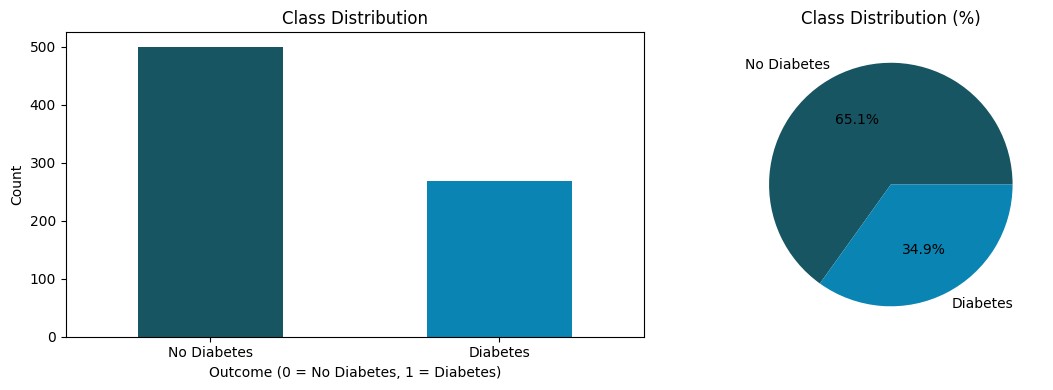

In [47]:
# Dataset is imbalanced: 65.1% no diabetes, 34.9% diabetes
# As a result a naive model always predicting 'no diabetes' would achieve 65% accuracy
# This represents Recall as a more meaningful metric that Accuracy alone

# Plot distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df['Outcome'].value_counts().plot(kind='bar', ax=axes[0], color=['#175562', '#0984b3'])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)

# Pie chart
df['Outcome'].value_counts().plot(kind='pie', ax=axes[1],
                                   labels=['No Diabetes', 'Diabetes'],
                                   autopct='%1.1f%%',
                                   colors=['#175562', '#0984b3'])
axes[1].set_title('Class Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

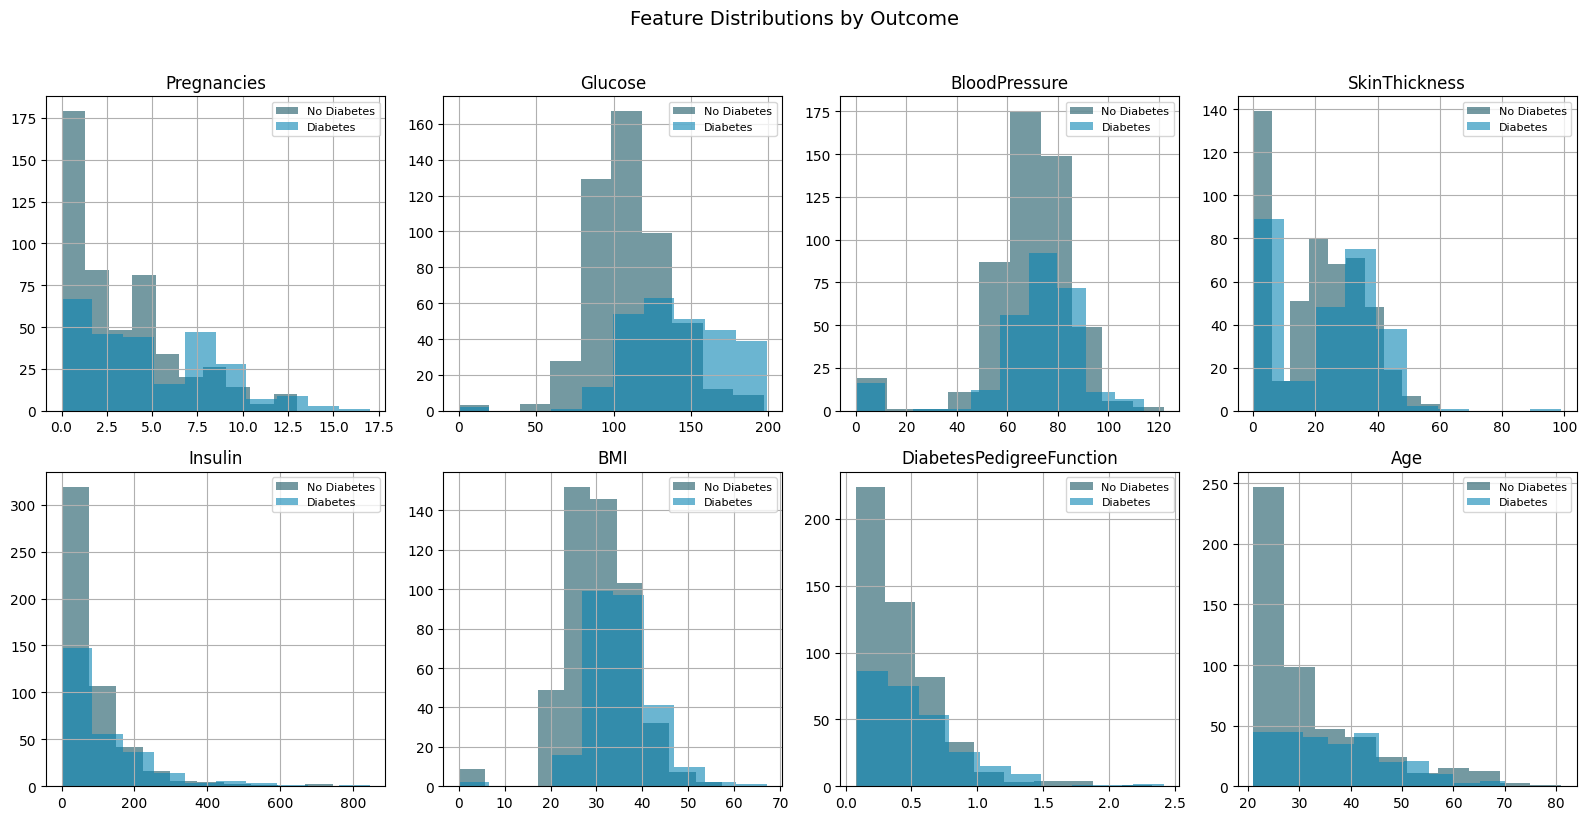

In [48]:
# Distribution of all features
# Distribution underlines the thesis that
# especially Glucose and BMI are highly accurate predictors for diabetes
# The Insulin distributions refers to the zero values
# indicating missing data for diabetes and non-diabetes patients
# The distribution highlights that Skin Thickness, Blood Pressure and age
# show state relatively low predictive power of diabetes in the overall context
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    # Plot separately for diabetic and non-diabetic patients
    df[df['Outcome'] == 0][feature].hist(ax=axes[i], alpha=0.6,
                                          color='#175562', label='No Diabetes')
    df[df['Outcome'] == 1][feature].hist(ax=axes[i], alpha=0.6,
                                          color='#0984b3', label='Diabetes')
    axes[i].set_title(feature)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Outcome', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

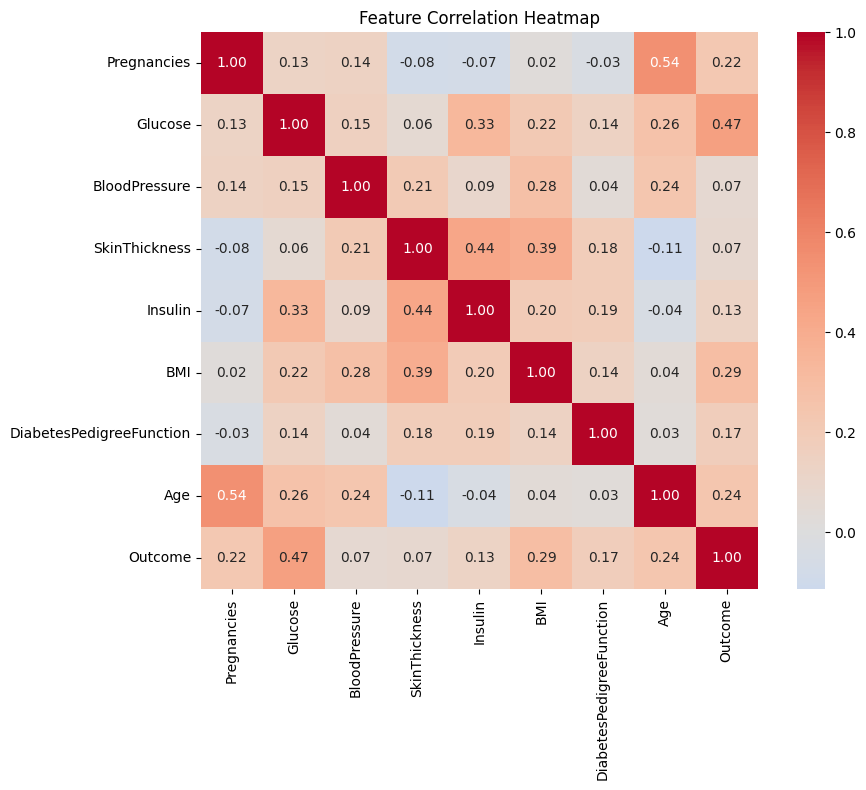

In [49]:
# Correlation heatmap - shows how features relate to each other
# Glucose shows the strongest correlation with Outcome (0.47)
# confirming it as the most relevant predictor for diabetes
# BMI (0.29) and Age (0.24) show moderate correlation with (Outcome)
# Pregnancies and Age are strongly correlated (0.54) which is expected
# as older women naturally had more time to accumulate pregnancies
# BloodPressure (0.07) and SkinThickness (0.07) show very little correlation with Outcome
# This demonstrates the limited predictive value these two factors have
# No multicollinearity issues have been detected between the main predictors
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing
We prepare the data for machine learning by splitting features (X) from the target variable (y),
and dividing the dataset into training and testing sets.

In [50]:
# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)  # All columns except Outcome
y = df['Outcome']               # Only the Outcome column

print('Features (X) shape:', X.shape)
print('Target (y) shape:', y.shape)
print('\nFeature names:', list(X.columns))

Features (X) shape: (768, 8)
Target (y) shape: (768,)

Feature names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [51]:
# Split into training set (80%) and test set (20%)
# random_state ensures reproducible results
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # Ensures same class ratio in train and test
)
# stratifiy=y ensures the 65/35 imbalance is maintained
# in both training and test set
# without stratify a random splitting could result in unrepresentative
# class distribution in either set

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Test set size:     {X_test.shape[0]} samples')

Training set size: 614 samples
Test set size:     154 samples


## 5. Model 1 — Decision Tree Classifier
A Decision Tree makes predictions by learning simple decision rules from the data.
It is easy to interpret but prone to overfitting.

In [52]:
# Train a Decision Tree model
dt_model = DecisionTreeClassifier(
    max_depth=5,           # Limit tree depth to prevent overfitting
    random_state=RANDOM_STATE
    # ensures reproducible results across runs
)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
dt_predictions = dt_model.predict(X_test)

# Evaluate performance
dt_accuracy = accuracy_score(y_test, dt_predictions)
print(f'Decision Tree Accuracy: {dt_accuracy:.4f} ({dt_accuracy:.1%})')
print('\nDetailed Classification Report:')
print(classification_report(y_test, dt_predictions,
                             target_names=['No Diabetes', 'Diabetes']))
# No Diabetes: Precision 0.84, Recall 0.84
# This means the model identifies non-diabetic patients well
# Diabetes: Precision 0.7, Recall 0.7
# Model shows lower performance in diabetic prediction
# This is explained as a result of the class imbalance (65/35)
# A Recall of 0.70 means 30% of diabetic patients are not detected
# This is a clinically critical (False Negative) result in medical diagnosis
# A higher recall for Diabetes class would be advisable

Decision Tree Accuracy: 0.7922 (79.2%)

Detailed Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.84      0.84      0.84       100
    Diabetes       0.70      0.70      0.70        54

    accuracy                           0.79       154
   macro avg       0.77      0.77      0.77       154
weighted avg       0.79      0.79      0.79       154



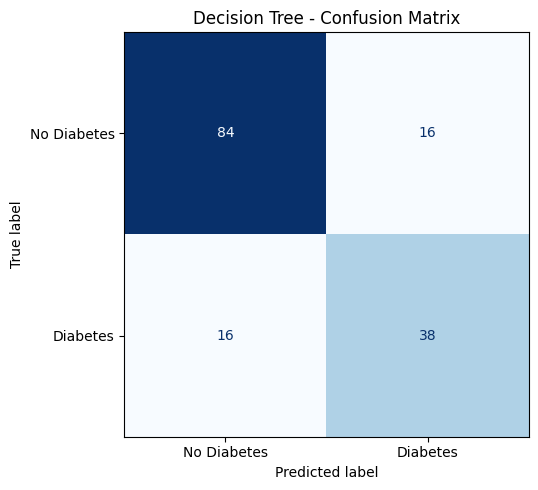

In [65]:
# Confusion Matrix for Decision Tree
# True Negatives: 84 - correctly identified as No Diabetes
# False Positive: 16 - patients incorrectly identified as Diabetic
# False Negative: 16 - patients incorrectly identified as healthy
# True Positive: 38 - correctly identified as Diabetic
# Results are based on test set (154 samples = 20% of total dataset)
# The test set represents the models' performance on unseen data
fig, ax = plt.subplots(figsize=(6, 5))
cm_dt = confusion_matrix(y_test, dt_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                               display_labels=['No Diabetes', 'Diabetes'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Decision Tree - Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_dt.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model 2 — Random Forest Classifier
A Random Forest builds many Decision Trees and combines their predictions (ensemble learning).
This reduces overfitting and generally leads to better performance than a single tree.

In [54]:
# Train a Random Forest model
# No Diabetes: Recall 0.85 - strong detection of healthy patients
# Diabetes: Recall 0.50 - only half of diabetic patients detected
# Low Recall for Diabetes likely caused by 65/35 class imbalance
# This is clinically critical as undetected cases remain untreated
rf_model = RandomForestClassifier(
    n_estimators=100,       # Number of trees in the forest
    max_depth=5,            # Max depth per tree
    random_state=RANDOM_STATE
)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

# Evaluate performance
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f'Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy:.1%})')
print('\nDetailed Classification Report:')
print(classification_report(y_test, rf_predictions,
                             target_names=['No Diabetes', 'Diabetes']))

Random Forest Accuracy: 0.7273 (72.7%)

Detailed Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.76      0.85      0.80       100
    Diabetes       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154



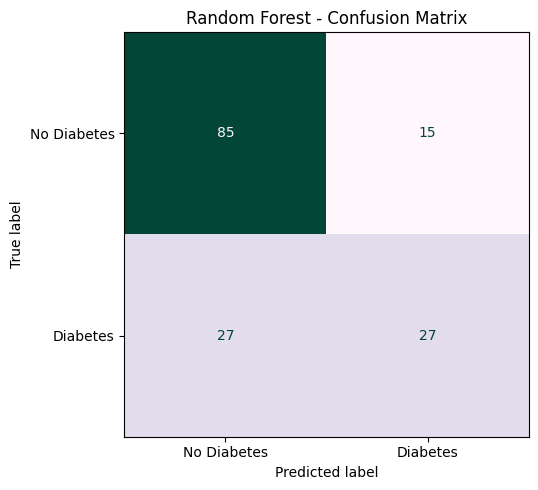

In [62]:
# Confusion Matrix for Random Forest
# True Negatives: 85
# False Positives: 15
# False Negatives: 27
# True Positives: 27
fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, rf_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['No Diabetes', 'Diabetes'])
disp.plot(ax=ax, cmap='PuBuGn', colorbar=False)
ax.set_title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Comparison
We compare both models side by side to analyze which performs better and why.

In [56]:
# Cross-validation for more reliable accuracy estimates
# Uses 5 different train/test splits and averages the results
dt_cv_scores = cross_val_score(dt_model, X, y, cv=5, scoring='accuracy')
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

print('=== Cross-Validation Results (5-Fold) ===')
print(f'Decision Tree: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std():.4f})')
print(f'Random Forest: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})')

=== Cross-Validation Results (5-Fold) ===
Decision Tree: 0.7488 (+/- 0.0357)
Random Forest: 0.7787 (+/- 0.0262)


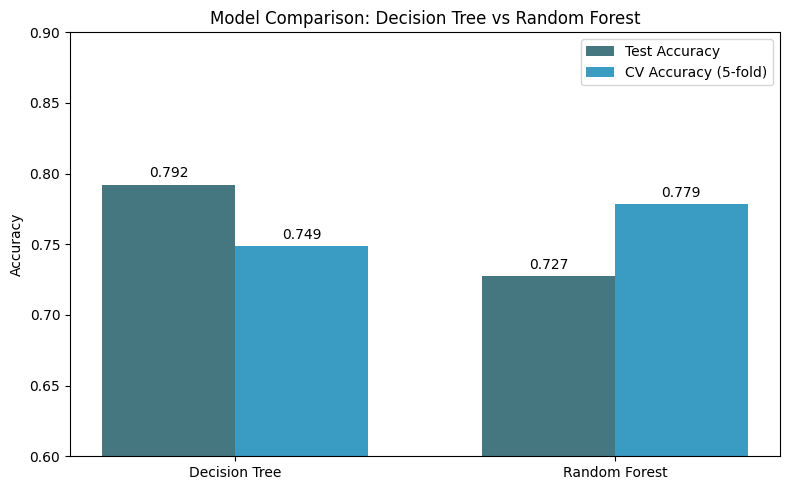

In [57]:
# Side-by-side accuracy comparison
# Decision Tree shows higher accuracy in test than Random Forest
# Random Forest performs better in CV accuracy
# Decision Tree indicates mild overfitting
# And Random Forest shows better generalisation for unknown data
models = ['Decision Tree', 'Random Forest']
test_accuracies = [dt_accuracy, rf_accuracy]
cv_accuracies = [dt_cv_scores.mean(), rf_cv_scores.mean()]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, test_accuracies, width,
               label='Test Accuracy', color='#175562', alpha=0.8)
bars2 = ax.bar(x + width/2, cv_accuracies, width,
               label='CV Accuracy (5-fold)', color='#0984b3', alpha=0.8)

ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: Decision Tree vs Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.6, 0.9)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance
One advantage of tree-based models is that they can tell us which features were most
important for making predictions. This provides valuable medical insights.

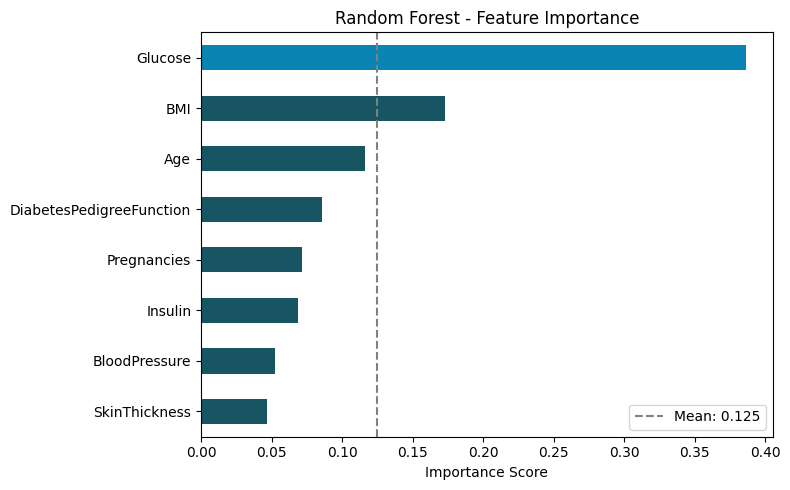


Top 3 most important features:
Glucose    0.385987
BMI        0.172660
Age        0.116051
dtype: float64


In [58]:
# Extract feature importances from the Random Forest
# Glucose dominates with 38.6% importance
# which confirms medical literature
# SkinThickness and BloodPressure below mean
# which states limited predictive value
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

# Plot feature importances
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#0984b3' if v == feature_importances.max() else '#175562'
          for v in feature_importances]
feature_importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Random Forest - Feature Importance')
ax.set_xlabel('Importance Score')
ax.axvline(x=feature_importances.mean(), color='gray',
            linestyle='--', label=f'Mean: {feature_importances.mean():.3f}')
ax.legend()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 3 most important features:')
print(feature_importances.sort_values(ascending=False).head(3))

## 9. Summary and Conclusions

In [59]:
# Final summary table
# CV Std Dev shows Random Forest is more stable
# Lowe std deviation means more consistent results across
# different data splits
summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Test Accuracy': [f'{dt_accuracy:.4f}', f'{rf_accuracy:.4f}'],
    'CV Accuracy (mean)': [f'{dt_cv_scores.mean():.4f}', f'{rf_cv_scores.mean():.4f}'],
    'CV Std Dev': [f'{dt_cv_scores.std():.4f}', f'{rf_cv_scores.std():.4f}']
})

print('=== FINAL RESULTS SUMMARY ===')
print(summary.to_string(index=False))
print()

# Determine winner
if rf_accuracy > dt_accuracy:
    improvement = (rf_accuracy - dt_accuracy) / dt_accuracy * 100
    print(f'Random Forest outperforms Decision Tree by {improvement:.1f}%')
    print('This confirms that ensemble methods generally outperform single models.')
else:
    print('Decision Tree performed comparably — consider tuning hyperparameters.')

print(f'\nMost predictive feature: {feature_importances.idxmax()}')
print('This aligns with medical literature on diabetes risk factors.')

=== FINAL RESULTS SUMMARY ===
        Model Test Accuracy CV Accuracy (mean) CV Std Dev
Decision Tree        0.7922             0.7488     0.0357
Random Forest        0.7273             0.7787     0.0262

Decision Tree performed comparably — consider tuning hyperparameters.

Most predictive feature: Glucose
This aligns with medical literature on diabetes risk factors.


In [60]:
#Type 2 Diabetes focused model - only key factors for Type 2 risk
type2_features = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']
x_type2 = df[type2_features]

x_train_t2, x_test_t2, y_train_t2, y_test_t2 = train_test_split(
    x_type2, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

rf_type2 = RandomForestClassifier( n_estimators=100, random_state=RANDOM_STATE)
rf_type2.fit(x_train_t2, y_train_t2)
rf_type2_predictions = rf_type2.predict(x_test_t2)
rf_type2_accuracy = accuracy_score(y_test_t2, rf_type2_predictions
)

print(f'Random Forest (All Features): {rf_accuracy:.4f}')
print(f'Random Forest (Type 2 Focus): {rf_type2_accuracy:.4f}')

Random Forest (All Features): 0.7273
Random Forest (Type 2 Focus): 0.7273


In [61]:
# Recall comparison - medically more relevant than accuracy
from sklearn.metrics import recall_score
dt_recall = recall_score(y_test, dt_predictions)
rf_recall = recall_score(y_test, rf_predictions)
t2_recall = recall_score(y_test_t2, rf_type2_predictions)

print(f'Decision Tree Recall:      {dt_recall:.4f}')
print(f'Random Forest Recall:      {rf_recall:.4f}')
print(f'Type 2 Focus Recall:       {t2_recall:.4f}')
# In medical diagnosis recall is more critical than accuracy

Decision Tree Recall:      0.7037
Random Forest Recall:      0.5000
Type 2 Focus Recall:       0.5370


## References

- Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). *Using the ADAP learning algorithm to forecast the onset of diabetes mellitus*. Proceedings of the Annual Symposium on Computer Application in Medical Care, 261.
- Kaggle Dataset: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
- Scikit-learn Documentation: https://scikit-learn.org/stable/modules/ensemble.html#forests-of-randomized-trees
- Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5–32.

---
*This notebook was developed with reference to public Kaggle notebooks on the Pima Indians Diabetes dataset.*  
*AI Declaration: APPENDIX I:  STUDENT DECLARATION OF ACADEMIC INTEGRITY

Students may be required to submit work for assessment in a variety of means, for example physical submission or electronic submission as per the lecturer’s instructions. In all cases students must make a declaration of academic integrity, either by physically completing such a declaration and submitting it with their assignment or engaging appropriately with the electronic version of the declaration on Loop. Assignments submitted such that the form has not been included, or the electronic equivalent has been circumvented, will not be accepted.

DECLARATION

NAME:	Jenny Höglauer
STUDENT ID NUMBER	46523
PROGRAMME	Global Business (EBG)
MODULE CODE	BA1027
ASSIGNMENT TITLE	Diabetes Prediction using Decision Trees and Random Forest
SUBMISSION DATE	20/04/2026


I understand that the University regards academic misconduct as grave and serious.

I have read and understood the DCU Academic Integrity Policy. I accept the penalties that may be imposed should I engage in academic misconduct.

I have identified and included the source of all facts, ideas, opinions and viewpoints of others in the assignment references. Direct quotations, paraphrasing, discussion of ideas from books, journal articles, internet sources, module text, or any other source whatsoever are acknowledged and the sources cited are identified in the assignment references.

I have not made unauthorised use of artificial intelligence aids.

I declare that this material, which I now submit for assessment, is entirely my own work and has not been taken from the work of others save and to the extent that such work has been cited and acknowledged within the text of my work.

I have used the DCU library referencing guidelines (available at https://www.dcu.ie/library/citing-referencing and/or the appropriate referencing system recommended in the assignment guidelines and/or programme documentation.

By signing this form or by submitting material online I confirm that this assignment, or any part of it, has not been previously submitted by me or any other person for assessment on this or any other course of study.

By signing this form or by submitting material for assessment online I confirm that I have read and understood the DCU Academic Integrity Policy

Signature: Jenny Höglauer


Date 20/04/2026
